In [ ]:
# ============================================================
# ⚙️ Install PyTorch Geometric + Dependencies + Kaggle Support
# ============================================================

!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric kaggle -q

import os, shutil, importlib

# Mount Drive (skip if already mounted)
from google.colab import drive
drive.mount('/content/my_drive', force_remount=True)

# Backup directory
backup_dir = "/content/my_drive/MyDrive/torch_geometric_libs"
os.makedirs(backup_dir, exist_ok=True)

# List of packages to back up
pkgs = ["torch_geometric", "torch_scatter", "torch_sparse", "torch_cluster", "torch_spline_conv"]

# Copy each installed package to Drive for reuse
for pkg in pkgs:
    try:
        mod = importlib.import_module(pkg)
        src = os.path.dirname(mod.__file__)
        shutil.copytree(src, os.path.join(backup_dir, pkg), dirs_exist_ok=True)
        print(f"✅ {pkg} backed up successfully.")
    except Exception as e:
        print(f"⚠️ Skipping {pkg}: {e}")

print("\n✅ All PyTorch Geometric components installed and backed up.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... canceled
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 95, in resolve
    result = self._result = resolver.resolve(
                            ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_vendor/r

KeyboardInterrupt: 

In [ ]:
import sys
from google.colab import drive

# Mount Google Drive to a new folder to avoid conflicts
drive.mount('/content/my_drive', force_remount=True)

# Set your backup directory inside the mounted drive
backup_dir = "/content/my_drive/MyDrive/torch_geometric_libs"
sys.path.insert(0, backup_dir)

print("✅ PyTorch Geometric loaded directly from Drive.")


Mounted at /content/my_drive
✅ PyTorch Geometric loaded directly from Drive.


In [ ]:
import sys
from google.colab import drive

# 1️⃣ Mount your Google Drive (if not already mounted)
drive.mount('/content/my_drive', force_remount=True)

# 2️⃣ Add the folder where PyG is saved to Python path
backup_dir = "/content/my_drive/MyDrive/torch_geometric_libs"
sys.path.insert(0, backup_dir)

# 3️⃣ Import PyTorch and PyG modules
import torch
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

print("✅ PyTorch Geometric is ready to use from Drive.")


Mounted at /content/my_drive
✅ PyTorch Geometric is ready to use from Drive.


In [ ]:
import os
from google.colab import files

# Path where Kaggle API token should be
KAGGLE_PATH = os.path.expanduser("~/.kaggle/kaggle.json")

# Check if token exists
if not os.path.exists(KAGGLE_PATH):
    print("Kaggle API token not found. Please upload kaggle.json:")
    uploaded = files.upload()
    if 'kaggle.json' not in uploaded:
        raise Exception("You must upload kaggle.json to proceed!")

    # Create .kaggle folder and move token
    os.makedirs(os.path.dirname(KAGGLE_PATH), exist_ok=True)
    with open(KAGGLE_PATH, 'wb') as f:
        f.write(uploaded['kaggle.json'])
    os.chmod(KAGGLE_PATH, 0o600)
    print("Kaggle API token uploaded and permissions set.")
else:
    print("Kaggle API token already exists.")

# Quick test: list top 5 datasets related to HAM10000
!kaggle datasets list -s ham10000 | head -n 5


Kaggle API token not found. Please upload kaggle.json:


Saving kaggle.json to kaggle.json
Kaggle API token uploaded and permissions set.
ref                                                          title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  -----------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
kmader/skin-cancer-mnist-ham10000                            Skin Cancer MNIST: HAM10000                       5582914511  2018-09-20 20:36:13.037000         225642       2166  0.7058824        
surajghuwalewala/ham1000-segmentation-and-classification     Skin cancer: HAM10000                             2781385274  2021-05-27 09:08:46.813000          16615        126  0.9411765        
tschandl/ham10000-lesion-segmentations                       HAM10000 Lesion Segmentations                       10766207  2020-07-02 21:20

In [ ]:
# Download dataset via Kaggle API
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

# Unzip dataset
!unzip -q skin-cancer-mnist-ham10000.zip -d /content/HAM10000


Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.19G/5.20G [02:12<00:00, 198MB/s]
100% 5.20G/5.20G [02:12<00:00, 42.2MB/s]


# **Cell 1: Setup & Imports**

In [ ]:
import os, random, glob, shutil, numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import transforms
from torchvision.models.vision_transformer import vit_b_16, ViT_B_16_Weights
from torchvision.transforms.autoaugment import RandAugment
from PIL import Image
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from torch_geometric.nn import GCNConv

# ---------------- Config ----------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "/content/HAM10000"
IMG_DIR1 = os.path.join(DATA_DIR, "HAM10000_images_part_1")
IMG_DIR2 = os.path.join(DATA_DIR, "HAM10000_images_part_2")
META_CSV = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

OUTPUT_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 300
LR = 5e-5   # lower for ViT fine-tuning


# **Cell 2: Consolidate Images**

In [ ]:
images_dir = os.path.join(os.getcwd(), "HAM10000_images")
os.makedirs(images_dir, exist_ok=True)

for d in [IMG_DIR1, IMG_DIR2]:
    for jpg in glob.glob(os.path.join(d, "*.jpg")):
        dst = os.path.join(images_dir, os.path.basename(jpg))
        if not os.path.exists(dst):
            shutil.copy2(jpg, dst)


# **Cell 3: Dataset & Augmentations**

In [ ]:
# ===============================
# 📊 Load metadata and prepare labels
# ===============================
meta = pd.read_csv(META_CSV)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
meta['label'] = le.fit_transform(meta['dx'])

# Save mapping for reference
label_map = {i: c for i, c in enumerate(le.classes_)}
print("✅ Classes:", label_map)

# ===============================
# 🧩 Data Augmentation
# ===============================
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
import os

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),   # slightly stronger crop
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),  # new
    transforms.ToTensor(),
    # ⚠️ Use the same normalization as ImageNet (ViT expects this)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2))
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ===============================
# 🧾 Dataset Class
# ===============================
class SkinDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_id'] + ".jpg")
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = int(row['label'])
        return img, label


✅ Classes: {0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}


# **Cell 4: Train/Val/Test Split + Balancing**

In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

# ===============================
# 🧩 Split the dataset (Stratified for balance)
# ===============================
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(meta, test_size=0.3, stratify=meta['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ===============================
# 🖼️ Create Datasets
# ===============================
train_ds = SkinDataset(train_df, images_dir, train_tfms)
val_ds   = SkinDataset(val_df, images_dir, val_tfms)
test_ds  = SkinDataset(test_df, images_dir, val_tfms)

# ===============================
# ⚖️ Handle Class Imbalance (Weighted Sampling)
# ===============================
class_counts = train_df['label'].value_counts().to_dict()
num_samples = len(train_df)
weights = [1.0 / class_counts[label] for label in train_df['label']]

sampler = WeightedRandomSampler(weights, num_samples=num_samples, replacement=True)

# ===============================
# 📦 DataLoaders
# ===============================
BATCH_SIZE = 32  # (If GPU memory allows, try 64 for smoother gradients)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("✅ DataLoaders ready.")


Train: 7010 | Val: 1502 | Test: 1503
✅ DataLoaders ready.


# **# Cell 5: ViT + GCN Model**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.vision_transformer import vit_b_16, ViT_B_16_Weights
from torch_geometric.nn import GCNConv

# ====================================
# 🧠 Upgraded ViT + GCN Hybrid
# ====================================
class ViT_GCN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # 1️⃣ ViT backbone
        self.vit = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
        self.vit.heads = nn.Identity()  # remove classifier
        self.vit.requires_grad_(False)   # freeze early layers for stability

        # 2️⃣ Projection head (trainable)
        self.vit_proj = nn.Sequential(
            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 256)
        )

        # 3️⃣ GCN layers
        self.gcn1 = GCNConv(256, 256)
        self.gcn2 = GCNConv(256, 256)

        # 4️⃣ Fusion + classifier
        self.alpha = nn.Parameter(torch.tensor(0.6))  # slightly favor ViT
        self.norm = nn.LayerNorm(256)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, img):
        # -------------------------------
        # 1️⃣ ViT feature extraction
        # -------------------------------
        vit_features = self.vit(img)  # (B, 768)
        vit_features = self.vit_proj(vit_features)  # (B, 256)

        # -------------------------------
        # 2️⃣ Build adaptive adjacency
        # -------------------------------
        with torch.no_grad():
            sim = torch.cdist(vit_features, vit_features, p=2)
            threshold = torch.quantile(sim, 0.25)  # more selective connections
            edge_index = (sim < threshold).nonzero().T

        # -------------------------------
        # 3️⃣ Graph propagation
        # -------------------------------
        gcn_features = F.relu(self.gcn1(vit_features, edge_index))
        gcn_features = F.dropout(gcn_features, p=0.3, training=self.training)
        gcn_features = F.relu(self.gcn2(gcn_features, edge_index))

        # -------------------------------
        # 4️⃣ Fusion + classification
        # -------------------------------
        fused = self.alpha * vit_features + (1 - self.alpha) * gcn_features
        fused = self.norm(fused)
        fused = self.dropout(fused)
        out = self.fc(fused)
        return out


# ====================================
# 🔧 Model initialization
# ====================================
num_classes = len(label_map)
model = ViT_GCN(num_classes).to(DEVICE)
print("✅ Model initialized:", model.__class__.__name__)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 122MB/s]


✅ Model initialized: ViT_GCN


# **Cell 6: Training Utilities (Mixup + CutMix + Scheduler)**

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.optim import AdamW
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

# =====================================
# ⚙️ Loss Function (Label Smoothing)
# =====================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# =====================================
# 🧠 Optimizer
# =====================================
# Use two parameter groups → freeze backbone LR lower, new layers higher
vit_params = []
new_params = []

for name, param in model.named_parameters():
    if "vit" in name:
        vit_params.append(param)
    else:
        new_params.append(param)

optimizer = AdamW([
    {"params": vit_params, "lr": 1e-5},    # smaller LR for pretrained ViT
    {"params": new_params, "lr": 3e-5},    # larger LR for new layers
], weight_decay=1e-4)

# =====================================
# 📈 Scheduler (Warmup + Cosine Annealing)
# =====================================
NUM_EPOCHS = 400  # (You can set based on your earlier code)
warmup = LinearLR(optimizer, start_factor=0.1, total_iters=5)
main_sched = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - 5)

scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup, main_sched],
    milestones=[5]
)

# =====================================
# 🔀 Mixup Augmentation
# =====================================
def mixup_data(x, y, alpha=0.4):
    """Applies mixup on input and targets."""
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print("✅ Optimizer, scheduler, and mixup ready.")


✅ Optimizer, scheduler, and mixup ready.


# **Cell 7: Training Loop with Best Model Saving**

In [ ]:
# ============================
# 🚀 Mount Google Drive first
# ============================
from google.colab import drive
drive.mount('/content/my_drive', force_remount=True)

import os
import torch
import random
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ============================
# 🧠 Paths to save checkpoints
# ============================
save_path = "/content/my_drive/MyDrive/vit_gcn_ham10000_best.pt"
checkpoint_path = "/content/my_drive/MyDrive/vit_gcn_checkpoint.pth"

best_acc = 0.0
start_epoch = 1

# ============================
# 🔄 Checkpoint loading
# ============================
if os.path.exists(checkpoint_path):
    print("🔄 Loading checkpoint from Google Drive...")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

    missing, unexpected = model.load_state_dict(checkpoint["model_state"], strict=False)
    print(f"✅ Model loaded. Missing keys: {missing}, Unexpected keys: {unexpected}")

    try:
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        scheduler.load_state_dict(checkpoint["scheduler_state"])
        print("✅ Optimizer and scheduler loaded.")
    except Exception as e:
        print(f"⚠️ Optimizer/Scheduler mismatch: {e}")
        print("➡️ Reinitializing optimizer and scheduler from scratch.")

    best_acc = checkpoint.get("best_acc", 0)
    start_epoch = checkpoint.get("epoch", 0) + 1

    print(f"✅ Resumed from epoch {start_epoch} | Best Val Acc = {best_acc:.4f}")
else:
    print("⚠️ No checkpoint found, starting fresh training...")
    start_epoch = 0
    best_acc = 0


# ============================
# 🏋️ Training Function
# ============================
def run_epoch(dl, train=True):
    model.train() if train else model.eval()
    total_loss, total_correct, total = 0, 0, 0

    if train and torch.cuda.is_available():
        scaler = torch.amp.GradScaler()

    for x, y in dl:
        x, y = x.to(DEVICE), y.to(DEVICE)

        if train:
            optimizer.zero_grad()
            with torch.amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
                out = model(x)
                loss = criterion(out, y)

            if torch.cuda.is_available():
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                optimizer.step()

            scheduler.step()

        else:
            with torch.no_grad():
                with torch.amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
                    out = model(x)
                    loss = criterion(out, y)

        pred = out.argmax(1)
        total += y.size(0)
        total_loss += loss.item() * y.size(0)
        total_correct += (pred == y).sum().item()

    return total_loss / total, total_correct / total


# ============================
# 🕒 Training Loop with Save
# ============================
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    # 🔓 Unfreeze ViT backbone for fine-tuning after 60 epochs
    # Unfreeze after 60 epochs
    if epoch == 60:
        for param in model.vit.parameters():
            param.requires_grad = True

        optimizer = torch.optim.AdamW([
            {"params": model.vit.parameters(), "lr": 2e-5},   # smaller for ViT
            {"params": model.gcn1.parameters(), "lr": 3e-5},
            {"params": model.gcn2.parameters(), "lr": 3e-5},
            {"params": model.fc.parameters(), "lr": 3e-5},
        ], weight_decay=1e-4)

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - epoch)
        print("🔓 Unfroze ViT backbone for fine-tuning with layer-wise LR!")


    tr_loss, tr_acc = run_epoch(train_loader, True)
    va_loss, va_acc = run_epoch(val_loader, False)

    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Acc: {tr_acc:.4f} | Val Acc: {va_acc:.4f}")

    # 💾 Save checkpoint
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_acc": best_acc
    }, checkpoint_path)
    print(f"✅ Checkpoint saved at epoch {epoch} → {checkpoint_path}")

    # 🏆 Save best model separately
    if va_acc > best_acc:
        best_acc = va_acc
        torch.save({"model": model.state_dict(), "classes": label_map}, save_path)
        print(f"🏆 Best model updated (Val Acc={best_acc:.4f}) → {save_path}")


Mounted at /content/my_drive
🔄 Loading checkpoint from Google Drive...
✅ Model loaded. Missing keys: [], Unexpected keys: []
✅ Optimizer and scheduler loaded.
✅ Resumed from epoch 265 | Best Val Acc = 0.9547
Epoch 265/400 | Train Acc: 0.9341 | Val Acc: 0.9501
✅ Checkpoint saved at epoch 265 → /content/my_drive/MyDrive/vit_gcn_checkpoint.pth
Epoch 266/400 | Train Acc: 0.9415 | Val Acc: 0.9547
✅ Checkpoint saved at epoch 266 → /content/my_drive/MyDrive/vit_gcn_checkpoint.pth


KeyboardInterrupt: 

# **Cell 8: Final Evaluation on Test Set**

In [ ]:
# ============================
# 🧩 Load Best Model for Evaluation
# ============================
checkpoint = torch.load(save_path, map_location=DEVICE)

# Handle both types of saved checkpoints (some use "model", some use full state_dict)
if "model" in checkpoint:
    model.load_state_dict(checkpoint["model"])
else:
    model.load_state_dict(checkpoint)

model.to(DEVICE)
model.eval()

# ============================
# 📊 Evaluate on Test Set
# ============================
test_loss, test_acc = run_epoch(test_loader, train=False)
print(f"✅ Final Test Accuracy: {test_acc*100:.2f}%")


✅ Final Test Accuracy: 94.08%


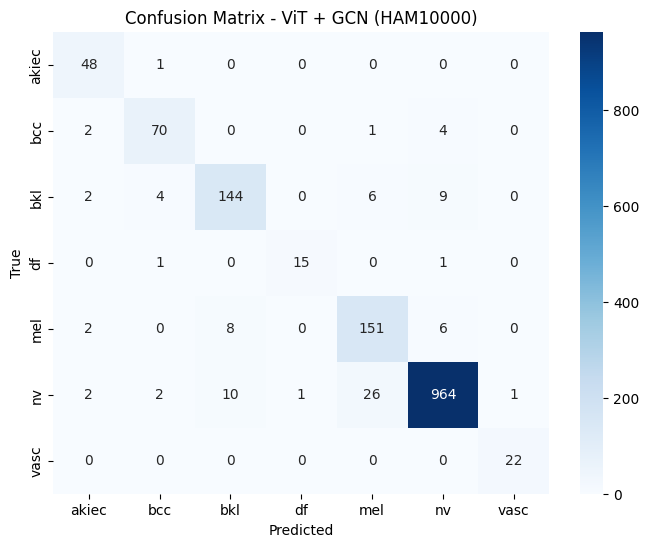

📊 Classification Report:
              precision    recall  f1-score   support

       akiec       0.86      0.98      0.91        49
         bcc       0.90      0.91      0.90        77
         bkl       0.89      0.87      0.88       165
          df       0.94      0.88      0.91        17
         mel       0.82      0.90      0.86       167
          nv       0.98      0.96      0.97      1006
        vasc       0.96      1.00      0.98        22

    accuracy                           0.94      1503
   macro avg       0.91      0.93      0.92      1503
weighted avg       0.94      0.94      0.94      1503



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- 1️⃣ Collect predictions ---
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        preds = out.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# --- 2️⃣ Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.values(), yticklabels=label_map.values())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - ViT + GCN (HAM10000)")
plt.show()

# --- 3️⃣ Classification Report ---
print("📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=list(label_map.values())))


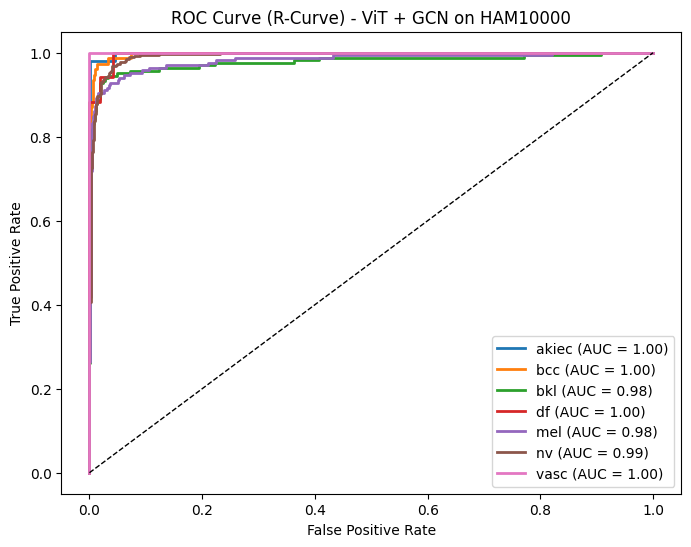

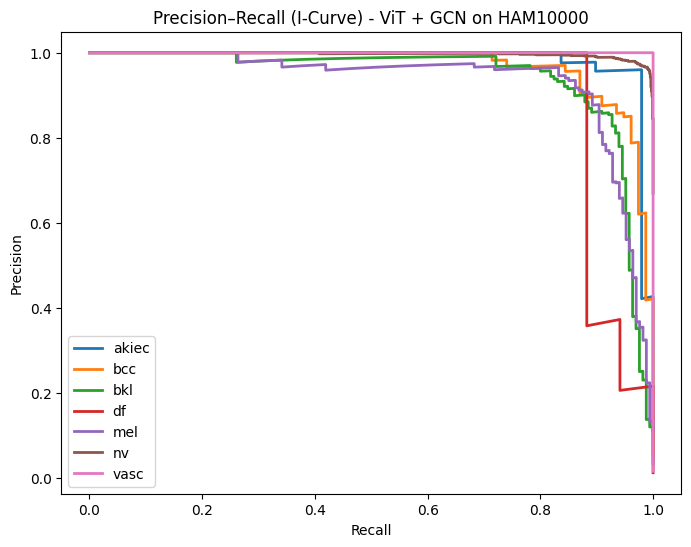

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# Ensure your model & test_loader are ready
model.eval()
all_labels, all_probs = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        probs = torch.softmax(out, dim=1)
        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Binarize labels for multi-class ROC/PR
n_classes = len(label_map)
y_bin = label_binarize(all_labels, classes=list(range(n_classes)))

# --- 🧩 1️⃣ ROC Curve (R-Curve) ---
plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{label_map[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (R-Curve) - ViT + GCN on HAM10000")
plt.legend()
plt.show()

# --- 🧩 2️⃣ Precision–Recall Curve (I-Curve) ---
plt.figure(figsize=(8,6))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], all_probs[:, i])
    plt.plot(recall, precision, lw=2, label=f'{label_map[i]}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall (I-Curve) - ViT + GCN on HAM10000")
plt.legend()
plt.show()


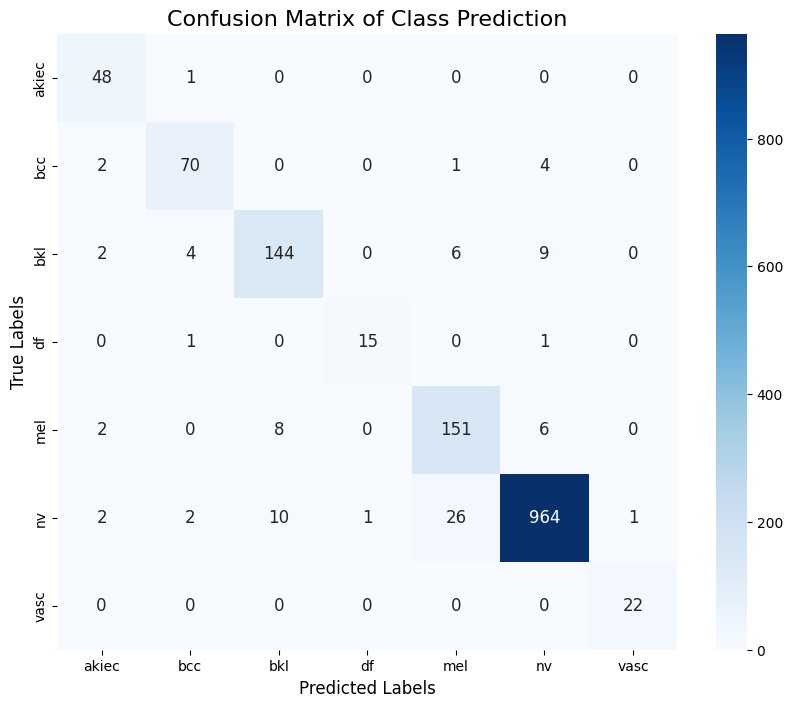


           Classification Report

              precision    recall  f1-score   support

       akiec       0.86      0.98      0.91        49
         bcc       0.90      0.91      0.90        77
         bkl       0.89      0.87      0.88       165
          df       0.94      0.88      0.91        17
         mel       0.82      0.90      0.86       167
          nv       0.98      0.96      0.97      1006
        vasc       0.96      1.00      0.98        22

    accuracy                           0.94      1503
   macro avg       0.91      0.93      0.92      1503
weighted avg       0.94      0.94      0.94      1503



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

# --- 1. Helper Function to Get Predictions ---
# (You can place this in a new cell)

def get_predictions(model, loader, device):
    """Utility function to get all predictions and labels from a dataloader."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            with torch.amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
                out = model(x)

            preds = out.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return all_labels, all_preds

# --- 2. Load Your Best Model & Get Data ---

# Define class names from your notebook's 'label_map' (Cell 3)
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

# Load the best model state (using path from your Cell 7)
save_path = "/content/my_drive/MyDrive/vit_gcn_ham10000_best.pt"
checkpoint = torch.load(save_path, map_location=DEVICE)

# Re-initialize your model structure (from Cell 5)
# Make sure 'num_classes' is defined (e.g., num_classes = 7)
model = ViT_GCN(num_classes=len(class_names))
model.load_state_dict(checkpoint["model"])
model.to(DEVICE)

# Get predictions using the test_loader (defined in Cell 4)
y_true, y_pred = get_predictions(model, test_loader, DEVICE)

# --- 3. Calculate and Plot Confusion Matrix ---

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12}) # Make annotations bigger

plt.title('Confusion Matrix of Class Prediction', fontsize=16)
plt.ylabel('True Labels', fontsize=12)
plt.xlabel('Predicted Labels', fontsize=12)
plt.show()

# --- 4. (Optional) Print Detailed Classification Report ---
print("\n" + "="*50)
print("           Classification Report")
print("="*50 + "\n")
print(classification_report(y_true, y_pred, target_names=class_names))